In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Dataset Shape: (2000, 17)

First 5 rows:
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1            

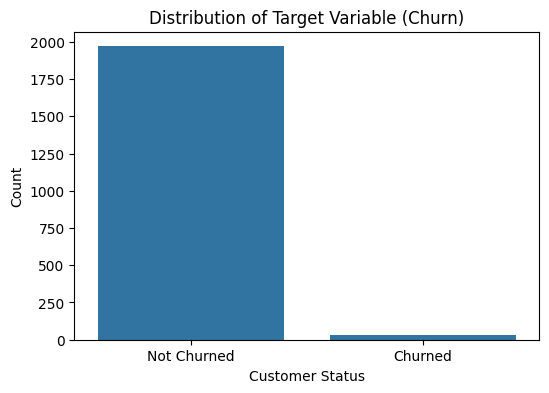

In [2]:
# Task 1: Dataset Understanding
df = pd.read_csv('../ai_project_synthetic_datasets/part_1_neural_network_analysis/customer_churn_nn.csv')

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())
print("\nTarget Variable Distribution (churn):")
print(df['churn'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.xticks(ticks=[0, 1], labels=['Not Churned', 'Churned'])
plt.title('Distribution of Target Variable (Churn)')
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.show()

In [3]:
# Task 2: Data Preprocessing
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# Identify features
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
num_cols = [col for col in X.columns if col not in cat_cols]

# 2. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

# 3. Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"Processed Training Shape: {X_train_scaled.shape}")
print(f"Processed Testing Shape: {X_test_scaled.shape}")

Processed Training Shape: (1600, 24)
Processed Testing Shape: (400, 24)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9368 - loss: 0.4091 - val_accuracy: 0.9812 - val_loss: 0.3284
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9806 - loss: 0.2724 - val_accuracy: 0.9937 - val_loss: 0.2165
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9826 - loss: 0.1929 - val_accuracy: 0.9937 - val_loss: 0.1501
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9833 - loss: 0.1479 - val_accuracy: 0.9937 - val_loss: 0.1110
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9833 - loss: 0.1228 - val_accuracy: 0.9937 - val_loss: 0.0885
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9833 - loss: 0.1083 - val_accuracy: 0.9937 - val_loss: 0.0750
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.0997 - val_accuracy: 0.9937 - val_loss: 0.0663
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9833 - loss: 0.0940 - val_accuracy: 0.9937 - val_loss:

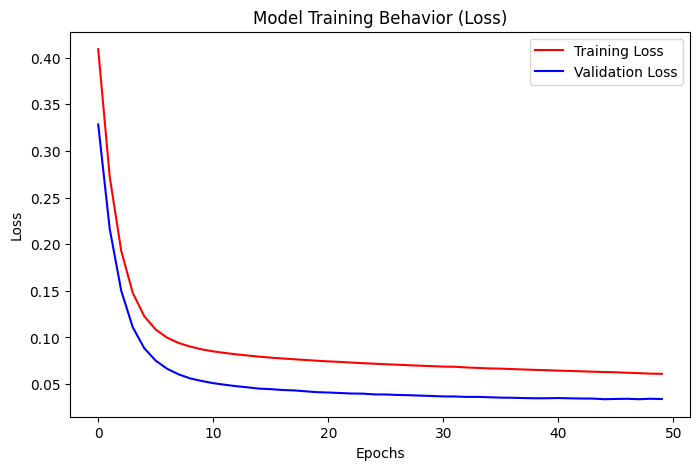

In [ ]:
# Task 3: Neural Network Model Building
import tensorflow as tf
from keras import models, layers, optimizers
import matplotlib.pyplot as plt

# Hyperparameters
learning_rate = 0.001
epochs = 50
batch_size = 32    # Standard for churn datasets
input_dim = X_train_scaled.shape[1] 

# Building the model
model = models.Sequential()

# Input Layer:
model.add(layers.Input(shape=(input_dim,)))

# Hidden Layer: 12 neurons
model.add(layers.Dense(units=12, activation='relu'))

# Output Layer: Sigmoid for binary classification (Churn 1/0)
model.add(layers.Dense(units=1, activation='sigmoid'))

# Compiling using Adam
model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training
history = model.fit(
    X_train_scaled, y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_split=0.1, 
    verbose=1
)

# Training and validation loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Model Training Behavior (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Neural Network Accuracy =  0.985
Neural Network Precision =  0.0
Neural Network Recall =  0.0
Neural Network F1 Score =  0.0
Training Loss: 0.0574, Training Accuracy: 0.9844
Testing Loss: 0.0544, Testing Accuracy: 0.9850


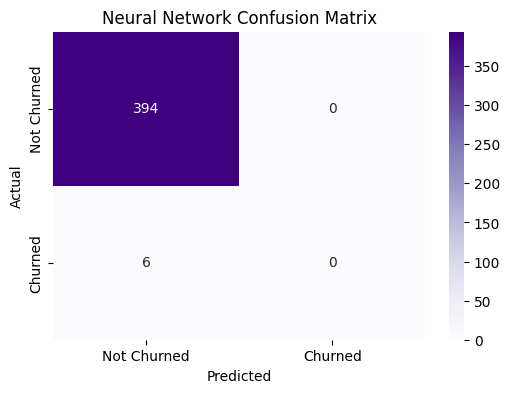

In [9]:
# Task 4: Training and Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Getting the model's predictions
y_pred_prob = model.predict(X_test_scaled)
nn_pred = (y_pred_prob > 0.5).astype(int)

print("Neural Network Accuracy = ", accuracy_score(y_test, nn_pred))
print("Neural Network Precision = ", precision_score(y_test, nn_pred, zero_division=0))
print("Neural Network Recall = ", recall_score(y_test, nn_pred))
print("Neural Network F1 Score = ", f1_score(y_test, nn_pred))

# Evaluating the Training set
train_loss, train_accuracy = model.evaluate(X_train_scaled, y_train, verbose=0)

# Evaluating the Testing set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Loss: {test_loss:.4f}, Testing Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
cm_nn = confusion_matrix(y_test, nn_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Churned', 'Churned'], 
            yticklabels=['Not Churned', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix')
plt.show()

In [6]:
# Task 5: Hyperparameter Experimentation
from keras import models, layers, Input, optimizers
results = []
input_dim = X_train_scaled.shape[1] # Needed for the Input layer

# run_experiment function
def run_experiment(name, hidden_layers, lr, epochs, batch_size, activation):
    model = models.Sequential()
    
    model.add(Input(shape=(input_dim,)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units=units, activation=activation))
        
    # Output layer
    model.add(layers.Dense(units=1, activation='sigmoid'))
    
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_scaled, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    
    train_loss, train_acc = model.evaluate(X_train_scaled, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    
    results.append({
        'Experiment': name,
        'Config': f"Layers:{hidden_layers}, LR:{lr}, Epochs:{epochs}, BS:{batch_size}, Act:{activation}",
        'Train Acc': round(train_acc, 4),
        'Test Acc': round(test_acc, 4),
        'Train Loss': round(train_loss, 4),
        'Test Loss': round(test_loss, 4)
    })

# Running the Experiments again
run_experiment("Base Model", [12], 0.01, 20, 32, 'relu')
run_experiment("Deeper Network", [16, 8], 0.01, 20, 32, 'relu')
run_experiment("Slower Learning", [12], 0.001, 50, 32, 'relu')
run_experiment("Tanh Activation", [12], 0.01, 20, 32, 'tanh')

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('model_comparison_table.csv', index=False)

     Experiment                                              Config  Train Acc  Test Acc  Train Loss  Test Loss
     Base Model    Layers:[12], LR:0.01, Epochs:20, BS:32, Act:relu     0.9869    0.9850      0.0333     0.0887
 Deeper Network Layers:[16, 8], LR:0.01, Epochs:20, BS:32, Act:relu     0.9950    0.9600      0.0162     0.1397
Slower Learning   Layers:[12], LR:0.001, Epochs:50, BS:32, Act:relu     0.9850    0.9850      0.0516     0.0615
Tanh Activation    Layers:[12], LR:0.01, Epochs:20, BS:32, Act:tanh     0.9887    0.9825      0.0375     0.0688
